In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge,LinearRegression,RidgeCV, LassoCV


In [2]:
np.random.seed(42)

# Reshape the data to be a 2D array with one column Required for sklearn models
X=np.linspace(0,10,40).reshape(-1,1)

#Add some relevant noise to the data
y=2 + 0.5 * X[:,0] + np.random.normal(0, 5, 40)

#Divide the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

degrees = [1,2,3,4.5,10]

#Include Bias=False to avoid adding an additional bias term since we are already including a bias term in the model
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

for degree in degrees:
    print(f"Polynomial Degree: {degree}, Train MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}")
    print()

Polynomial Degree: 1, Train MSE: 19.36, Test MSE: 26.40

Polynomial Degree: 2, Train MSE: 19.36, Test MSE: 26.40

Polynomial Degree: 3, Train MSE: 19.36, Test MSE: 26.40

Polynomial Degree: 4.5, Train MSE: 19.36, Test MSE: 26.40

Polynomial Degree: 10, Train MSE: 19.36, Test MSE: 26.40



In [3]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


np.random.seed(42)

# Reshape the data to a 2D array with one column
# Required for sklearn models
X = np.linspace(0, 500, 1000).reshape(-1, 1)

# Add some relevant noise to the data
y = 2 + 0.5 * X[:, 0] + np.random.normal(0, 5, len(X))

test_sizes = [0.2, 0.25, 0.30]
degrees = [1, 2, 3, 4, 5, 10]

# Divide the data into training and testing sets
for test_size in test_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # Try different polynomial degrees
    for degree in degrees:

        model = make_pipeline(
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            ),
            LinearRegression()
        )

        # Train the model
        model.fit(X_train, y_train)

        # Predictions
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)

        # Calculate MSE
        train_mse = mean_squared_error(
            y_train,
            train_predictions
        )

        test_mse = mean_squared_error(
            y_test,
            test_predictions
        )

        print(
            f"Test Size: {test_size}, "
            f"Polynomial Degree: {degree}, "
            f"Train MSE: {train_mse:.2f}, "
            f"Test MSE: {test_mse:.2f}"
        )

    print()


Test Size: 0.2, Polynomial Degree: 1, Train MSE: 23.96, Test MSE: 23.75
Test Size: 0.2, Polynomial Degree: 2, Train MSE: 23.95, Test MSE: 23.80
Test Size: 0.2, Polynomial Degree: 3, Train MSE: 79.35, Test MSE: 72.98
Test Size: 0.2, Polynomial Degree: 4, Train MSE: 238.23, Test MSE: 215.74
Test Size: 0.2, Polynomial Degree: 5, Train MSE: 457.96, Test MSE: 409.90
Test Size: 0.2, Polynomial Degree: 10, Train MSE: 1576.79, Test MSE: 1535.59

Test Size: 0.25, Polynomial Degree: 1, Train MSE: 23.75, Test MSE: 24.51
Test Size: 0.25, Polynomial Degree: 2, Train MSE: 23.75, Test MSE: 24.52
Test Size: 0.25, Polynomial Degree: 3, Train MSE: 78.75, Test MSE: 76.00
Test Size: 0.25, Polynomial Degree: 4, Train MSE: 235.96, Test MSE: 226.86
Test Size: 0.25, Polynomial Degree: 5, Train MSE: 453.59, Test MSE: 432.42
Test Size: 0.25, Polynomial Degree: 10, Train MSE: 1560.82, Test MSE: 1591.87

Test Size: 0.3, Polynomial Degree: 1, Train MSE: 23.77, Test MSE: 24.39
Test Size: 0.3, Polynomial Degree: 2, 

In [4]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


np.random.seed(42)

# Reshape the data to a 2D array with one column
# Required for sklearn models
X = np.linspace(0, 500, 1000).reshape(-1, 1)

# Add some relevant noise to the data
y = 2 + 0.5 * X[:, 0] + np.random.normal(0, 5, len(X))

test_sizes = [0.2, 0.25, 0.30]
degrees = [1, 2, 3, 4, 5, 10]

# Divide the data into training and testing sets
for test_size in test_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # Try different polynomial degrees
    for degree in degrees:

        model = make_pipeline(
            PolynomialFeatures(
                degree=degree,
                include_bias=True
            ),
            LinearRegression()
        )

        # Train the model
        model.fit(X_train, y_train)

        # Predictions
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)

        # Calculate MSE
        train_mse = mean_squared_error(
            y_train,
            train_predictions
        )

        test_mse = mean_squared_error(
            y_test,
            test_predictions
        )

        print(
            f"Test Size: {test_size}, "
            f"Polynomial Degree: {degree}, "
            f"Train MSE: {train_mse:.2f}, "
            f"Test MSE: {test_mse:.2f}"
        )

    print()


Test Size: 0.2, Polynomial Degree: 1, Train MSE: 23.96, Test MSE: 23.75
Test Size: 0.2, Polynomial Degree: 2, Train MSE: 23.95, Test MSE: 23.80
Test Size: 0.2, Polynomial Degree: 3, Train MSE: 79.35, Test MSE: 72.98
Test Size: 0.2, Polynomial Degree: 4, Train MSE: 238.23, Test MSE: 215.74
Test Size: 0.2, Polynomial Degree: 5, Train MSE: 457.96, Test MSE: 409.90
Test Size: 0.2, Polynomial Degree: 10, Train MSE: 1576.79, Test MSE: 1535.59

Test Size: 0.25, Polynomial Degree: 1, Train MSE: 23.75, Test MSE: 24.51
Test Size: 0.25, Polynomial Degree: 2, Train MSE: 23.75, Test MSE: 24.52
Test Size: 0.25, Polynomial Degree: 3, Train MSE: 78.75, Test MSE: 76.00
Test Size: 0.25, Polynomial Degree: 4, Train MSE: 235.96, Test MSE: 226.86
Test Size: 0.25, Polynomial Degree: 5, Train MSE: 453.59, Test MSE: 432.42
Test Size: 0.25, Polynomial Degree: 10, Train MSE: 1560.82, Test MSE: 1591.87

Test Size: 0.3, Polynomial Degree: 1, Train MSE: 23.77, Test MSE: 24.39
Test Size: 0.3, Polynomial Degree: 2, 

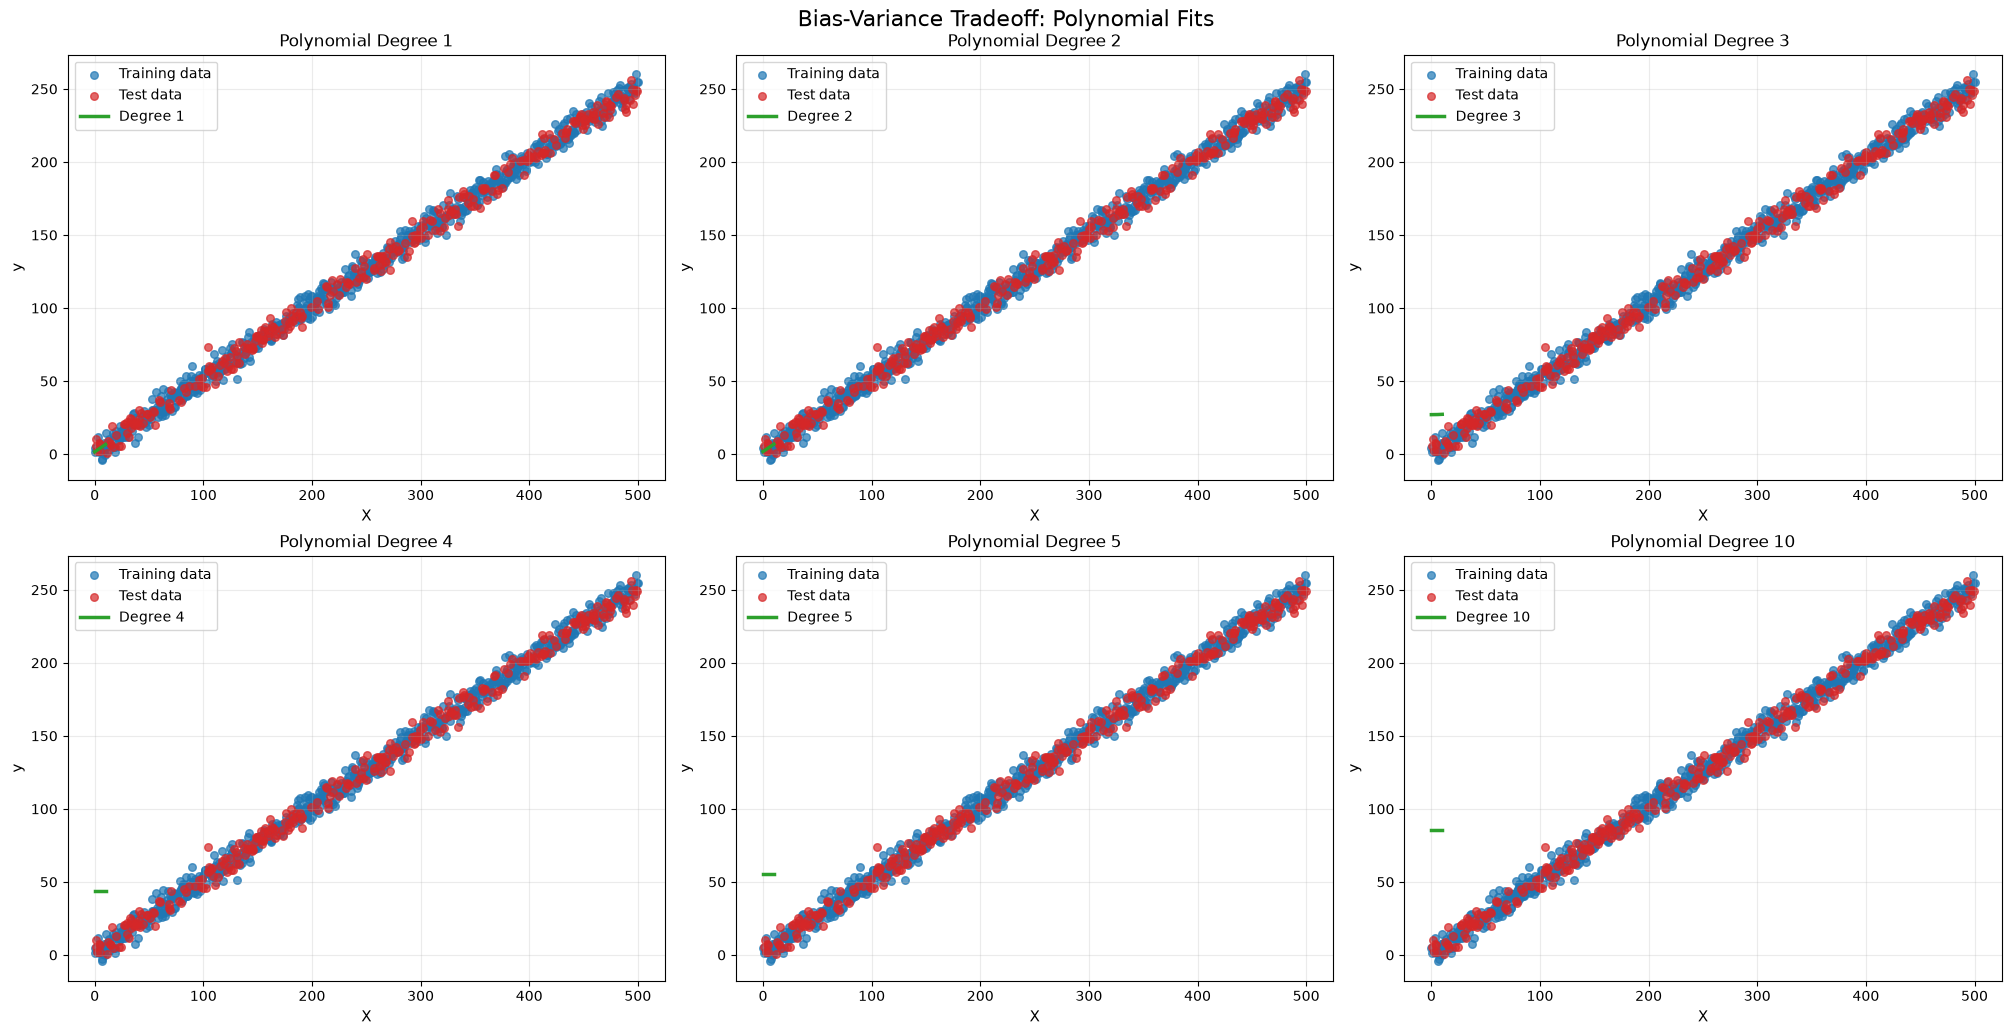

In [9]:
# Use valid integer degrees
degrees = [1, 2, 3, 4, 5, 10]

x_plot = np.linspace(0, 10, 500).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
axes = axes.ravel()

for ax, degree in zip(axes, degrees):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    y_plot = model.predict(x_plot)

    ax.scatter(X_train, y_train, s=30, color='tab:blue', alpha=0.7, label='Training data')
    ax.scatter(X_test, y_test, s=30, color='tab:red', alpha=0.7, label='Test data')
    ax.plot(x_plot[:, 0], y_plot, color='tab:green', linewidth=2.5, label=f'Degree {degree}')
    ax.set_title(f'Polynomial Degree {degree}', fontsize=12)
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best', frameon=True)

fig.suptitle('Bias-Variance Tradeoff: Polynomial Fits', fontsize=16, y=1.02)
plt.show()

In [ ]:
from sklearn